## Resistive tearing by autodiff eigenvalues, against exact theory

**Rung 1a of `plans/AUTODIFF_PLAN.md`.** The eigen-harness `taranis/stability.py` builds the
exact Jacobian of the solver's own discrete right-hand side, $J = L + N'(x_0)$ (`apply_L`
plus a `jax.jvp` of `construct_rhs`), about a frozen equilibrium $x_0$ -- no linearized
equations are ever written. This notebook checks that Jacobian's growth rates against
**exact** tearing theory, where every constant is known independently of taranis:

* the equilibrium is $\Psi_0=\mathrm{sech}^2 x$ (so $B_y=f(x)=-2\tanh x\,\mathrm{sech}^2x$,
  $f'(0)=-2$), whose outer-region stability index $\Delta'(k)$ is known in **closed form**
  (a Pöschl–Teller $\ell=3$ potential);
* the resistive inner layer obeys the **exact** (nonconstant-$\psi$) dispersion relation of
  Coppi, Galvão, Pellat, Rosenbluth & Rutherford (1976) / Ara et al. (1978), valid across
  the whole FKR $\leftrightarrow$ Coppi range.

Both are transcribed, and **verified numerically on their own** (sections 1-2), before a
single eigenvalue is compared with them. Then: the growth-rate ratio
$\gamma_{eig}/\gamma_{theory}\to1$ as $S\to\infty$ with a measured correction exponent
(§4), the fastest mode $\gamma_{max}(S)$, $k_{max}(S)$ (§5), the marginal point
$ka=\sqrt5$ (§6), the inner-layer width (§7), cross-checks against Alfred's Julia
eigencode and against the two time-domain tearing notebooks (§8), a second exact-$\Delta'$
family with two current sheets per period (§9), and the oscillatory "surprise" mode
(§10).

**Setup** (everything): `dims=2`, $\nu=0$ (`diss=(0, η)`), `hyper=1`, $a=v_{Ay}=1$,
$S=1/\eta$, $\Phi_0=0$, $L_y=2\pi/k$, `ny=8` (the $k_y=k$ column is `iky=1`), fp64. The
box is $L_x=\max(15/k,\,20)$ -- measured in §3 -- and $\Psi_0$ carries its two nearest periodic
images, so the periodic box sees no kink at its edge.

**Solver.** For a 1D equilibrium $J$ is block-diagonal in $k_y$ and the $k_y=k$ block is an
ordinary complex matrix on the dealias-kept $(\phi,\psi)(k_x)$ entries. Small grids:
`ky_block_matrix` + `eig_dense` (the *whole* spectrum -- this is what certifies "fastest
mode"). Large grids: `shift_invert(k=1)` on the matrix-free `ky_block_operator`, its GMRES
solves preconditioned by an exact sparse LU of the block's banded part (the sech$^2$
spectrum decays like $e^{-\pi q/2}$, so $J$ couples $k_x$ only within a band of
$\approx3.4L_x$ indices); the band is read off ~$2P$ operator probes by colouring, no dense
matrix is formed, and every returned pair passes the harness's residual gate against the
**exact** operator. Every reported $\gamma$ is converged by doubling $n_x$ until successive
values agree to $10^{-8}$; the residual $\|Jv-\lambda v\|/(|\lambda|\|v\|)$ is printed
next to it.

**Data.** `tearing_eigen_run.py` holds the theory, the solvers and a resumable
`make_data()`: each eigen-solve is cached as one small `.npz` under
`examples/data/tearing-eigen/` (gitignored), so the first execution computes (see the cost
cell at the end) and every later one only reads.

In [1]:
# fp64 must be selected before taranis/jax import (TARANIS_PRECISION is read at import)
import os
os.environ["TARANIS_PRECISION"] = "64"
import time
import numpy as np
import matplotlib.pyplot as plt
import tearing_eigen_run as T

t0 = time.time()
while not T.make_data(wall_budget=3600.0, log=lambda *a: None):
    pass          # resumable: each call does <= 1 h of missing solves; cached ones are free
print(f"data ready ({time.time() - t0:.0f} s this call)")

field variables are using 64bit precision.
data ready (1 s this call)


### 1. Outer region: $\Delta'(k)$ in closed form

Linearizing $\partial_t\nabla^2\phi+\{\phi,\nabla^2\phi\}=\{\psi,\nabla^2\psi\}$,
$\partial_t\psi+\{\phi,\psi\}=\eta\nabla^2\psi$ about $(\Phi_0,\Psi_0)=(0,\Psi_0(x))$ with
perturbations $\propto e^{\gamma t+iky}$ and dropping $\gamma$ and $\eta$ (ideal outer
region), the flux perturbation obeys
$$\psi''=\Big(k^2+\frac{f''}{f}\Big)\psi,\qquad f=\Psi_0'=-2\tanh x\,\mathrm{sech}^2x,
\qquad \frac{f''}{f}=4-12\,\mathrm{sech}^2x,$$
a Schrödinger equation with the reflectionless Pöschl–Teller potential
$-\ell(\ell+1)\mathrm{sech}^2x$, $\ell=3$, at energy $-\kappa^2=-(k^2+4)$. Its decaying
solution is generated by ladder operators, $\psi=A_3A_2A_1e^{-\kappa x}$ with
$A_\ell=-\mathrm{d}/\mathrm{d}x+\ell\tanh x$, and the tearing-parity jump
$\Delta'=[\psi']^{0^+}_{0^-}/\psi(0)=2\psi'(0^+)/\psi(0)$ is
$$\boxed{\;\Delta'a=\frac{2(5-k^2a^2)(k^2a^2+3)}{k^2a^2\sqrt{k^2a^2+4}}\;}
\;\xrightarrow{ka\to0}\;\frac{15}{(ka)^2}+\frac18,$$
marginal at exactly $ka=\sqrt5$. Three independent checks below: (a) $f''/f$ against finite
differences of $f$ itself; (b) sympy applies the ladder operators and forms $\Delta'$
symbolically, and the ladder solution's ODE residual is evaluated at 40-digit precision;
(c) numerical shooting of the outer ODE from $x=40$ inward.

In [2]:
import sympy as sp
import mpmath as mp

# (a) f''/f = 4 - 12 sech^2 x, against a 4th-order finite difference of f
f = lambda x: -2*np.tanh(x)/np.cosh(x)**2
xs = np.array([0.05, 0.3, 1.0, 2.5, 5.0]); h = 1e-3
fd = (-f(xs+2*h) + 16*f(xs+h) - 30*f(xs) + 16*f(xs-h) - f(xs-2*h))/(12*h*h)/f(xs)
print("(a) max |FD f''/f - (4 - 12 sech^2)| =", np.max(np.abs(fd - T.fpp_over_f_sech2(xs))))

# (b) the ladder solution, symbolically
x, k = sp.symbols("x k", positive=True)
kap = sp.sqrt(k**2 + 4)
A = lambda l, g: -sp.diff(g, x) + l*sp.tanh(x)*g
psi = A(3, A(2, A(1, sp.exp(-kap*x))))
D = sp.simplify(2*sp.diff(psi, x).subs(x, 0)/psi.subs(x, 0))
print("(b) Delta' from the ladder solution:", sp.factor(D))
print("    minus the boxed formula:", sp.simplify(D - 2*(5 - k**2)*(k**2 + 3)/(k**2*sp.sqrt(k**2 + 4))))
print("    small-k series:", sp.series(D, k, 0, 2))
res = sp.lambdify((x, k), sp.diff(psi, x, 2) - (k**2 + 4 - 12/sp.cosh(x)**2)*psi, "mpmath")
mp.mp.dps = 40
worst = max(abs(res(mp.mpf(xx), mp.mpf(kk))) for xx in (0.1, 0.7, 2.0, 6.0) for kk in (0.1, 1.0, 3.0))
print(f"    ODE residual of the ladder solution at 40 digits: {float(worst):.1e}")

# (c) shooting
print("\n(c)  ka      Delta'a (formula)     Delta'a (shooting)    rel. diff")
for ka in (0.05, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0):
    ex, sh = T.dprime_sech2(ka), T.dprime_shoot(ka)
    print(f"   {ka:5.2f}   {ex:20.12f}  {sh:20.12f}   {abs(sh/ex - 1):.1e}")
print(f"   sqrt5   {T.dprime_sech2(T.SQRT5):20.3e}  {T.dprime_shoot(T.SQRT5):20.3e}   (marginal)")

(a) max |FD f''/f - (4 - 12 sech^2)| = 5.544973369353556e-10
(b) Delta' from the ladder solution: -2*(k**2 - 5)*(k**2 + 3)/(k**2*sqrt(k**2 + 4))
    minus the boxed formula: 0
    small-k series: 15/k**2 + 1/8 + O(k**2)
    ODE residual of the ladder solution at 40 digits: 4.8e-39

(c)  ka      Delta'a (formula)     Delta'a (shooting)    rel. diff
    0.05      6000.122754522434     6000.122754496276   4.4e-12
    0.10      1500.116025471134     1500.116025469259   1.2e-12
    0.30       166.711593912028      166.711593912002   1.5e-13
    0.50        59.906299383974       59.906299383971   5.8e-14
    1.00        14.310835055999       14.310835055998   1.2e-14
    1.50         5.133333333333        5.133333333333   9.2e-15
    2.00         1.237436867076        1.237436867076   1.2e-14
    3.00        -2.958401046535       -2.958401046535   4.3e-14
   sqrt5             -9.474e-16            -3.142e-14   (marginal)


### 2. Inner layer: the exact resistive dispersion relation

**Transcription.** Boldyrev & Loureiro 2018, *Calculations in the theory of tearing
instability*, J. Phys.: Conf. Ser. **1100**, 012003 (arXiv:1809.00453), **eq. (60)**, which
they attribute to Coppi, Galvão, Pellat, Rosenbluth & Rutherford 1976 (Sov. J. Plasma Phys.
**2**, 533) -- their ref. [29] -- with the same Laguerre-expansion solution in Ara, Basu, Coppi,
Laval, Rosenbluth & Waddell 1978 (Ann. Phys. **112**, 443), ref. [30]:
$$-\frac{\pi}{8}\,\beta^{3/2}\,\frac{\Gamma\!\big(\frac{\beta-1}{4}\big)}{\Gamma\!\big(\frac{\beta+5}{4}\big)}=\lambda\,\Delta',
\qquad \lambda=\frac{\gamma}{kV_A},\quad \tilde\eta=\frac{\eta}{kV_Aa^2},\quad \beta^2=\frac{\lambda^3}{\tilde\eta}$$
(their eqs. 5-7; $\Delta'$ in units of $1/a$). It is derived for profiles with $f'(0)=1$ (their
tanh and sine). For $f\simeq f'(0)x$ in the layer, their inner equations (26)-(27)
$\lambda\psi-\xi\phi=\tilde\eta\psi''$, $-\xi\psi''=\lambda\phi''$ become exactly the $f'=1$
ones under $k\to k|f'(0)|$ (divide Ohm's law by $f'$ and rescale $\phi$), while $\Delta'$ -- a
property of the outer solution, matched through $\int\psi''$ -- is unchanged. With
$\Lambda\equiv\gamma/[\eta^{1/3}(k|f'|)^{2/3}]$ (so $\beta=\Lambda^{3/2}$) and
$\delta_\eta\equiv[\eta/(k|f'|)]^{1/3}$ the relation reads
$$\boxed{\;\Delta'\,\delta_\eta=F(\Lambda)\equiv-\frac{\pi}{8}\,\Lambda^{5/4}\,
\frac{\Gamma\!\big((\Lambda^{3/2}-1)/4\big)}{\Gamma\!\big((\Lambda^{3/2}+5)/4\big)}\;},
\qquad \gamma=\Lambda\,\eta^{1/3}(k|f'(0)|)^{2/3},\quad |f'(0)|=2 .$$
$F$ rises monotonically from 0 to $\infty$ on $0<\Lambda<1$, so each $\Delta'>0$ has one root.
This is the same relation `tearing-growth-vs-k.ipynb` uses (there in Fitzpatrick's
notation); Porcelli 1987 (Phys. Fluids **30**, 1734) gives the viscous generalization, which
reduces to it at $\nu=0$.

**Limits.** $\Lambda\to0$: $F\to C\Lambda^{5/4}$ with
$C=-\tfrac{\pi}{8}\Gamma(-\tfrac14)/\Gamma(\tfrac54)=\tfrac{\pi}{2}\Gamma(\tfrac34)/\Gamma(\tfrac54)=2\pi\Gamma(\tfrac34)/\Gamma(\tfrac14)=2.1236$,
giving FKR, $\gamma=C^{-4/5}\Delta'^{4/5}\eta^{3/5}(k|f'|)^{2/5}$ with
$C^{-4/5}=[\Gamma(\tfrac14)/(2\pi\Gamma(\tfrac34))]^{4/5}=0.5474$. $\Delta'\to\infty$: the root
goes to $\Lambda\to1$ (the pole of $\Gamma$ at 0), i.e. Coppi,
$\gamma=\eta^{1/3}(k|f'|)^{2/3}$. **A discrepancy in the source:** B&L's eq. (54) writes the
constant as $C=\frac{\pi}{2}\Gamma(\frac34)/\Gamma(\frac54)$ "$\approx1.45$"; the expression
evaluates to **2.124**, and 2.124 is what their own eq. (60) reduces to at $\beta\to0$
(checked below) -- so "1.45" is an arithmetic slip, not a different constant. The FKR
prefactor 0.547 agrees with the standard $\gamma\simeq0.55\,\Delta'^{4/5}\eta^{3/5}(kB')^{2/5}$.

**Independent check of $F$.** Rather than trust the Γ-function algebra, the inner-layer ODEs
are solved numerically. In $s=x/\delta_\eta$, with $\phi=-iu$, the layer equations are
$\psi''=\Lambda\psi-su$, $u''=-s\psi+s^2u/\Lambda$ (the same system as B&L 26-27); impose
$\psi'(0)=0$, $u(0)=0$ (tearing parity), $\psi(0)=1$, and at $s_{max}$ the non-exponential
branch $u=\Lambda\psi/s$; then $\psi\to c_0+c_1s$ and $\Delta'\delta_\eta=2c_1/c_0$. The
truncation error is $O(s_{max}^{-2})$ (measured), removed by Richardson extrapolation over
$s_{max}=40,80$.

In [3]:
print(f"C = (pi/2) G(3/4)/G(5/4) = {T.C_FKR:.6f}   (B&L 2018 eq. 54 prints '~1.45')")
print(f"FKR prefactor C^(-4/5) = {T.C_FKR**-0.8:.6f};  [G(1/4)/(2 pi G(3/4))]^(4/5) = "
      f"{(T.Gfun(0.25)/(2*np.pi*T.Gfun(0.75)))**0.8:.6f}")
print(f"small-Lambda limit of eq. (60): F(1e-8)/1e-8^(5/4) = {T.inner_F(1e-8)/1e-10:.6f}\n")

print(" Lambda      F (Gamma form)      numerical inner solve   rel. diff   (raw smax=40, 80)")
for Q in (1e-3, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.97):
    ext, raw = T.inner_F_numeric(Q)
    F = T.inner_F(Q)
    print(f" {Q:6.3f}  {F:18.10f}  {ext:20.10f}   {abs(ext/F - 1):.1e}    "
          f"({abs(raw[0]/F - 1):.1e}, {abs(raw[1]/F - 1):.1e})")

# the two asymptotic branches, from the root of the exact relation
print("\nFKR limit (small Delta' delta):   gamma_exact/gamma_FKR")
for Dd in (1e-4, 1e-3, 1e-2, 0.1):
    lam = T.lam_of(Dd)
    print(f"   Delta' delta_eta = {Dd:6.0e}:  {lam/(Dd/T.C_FKR)**0.8:.6f}")
print("Coppi limit (Delta' -> inf):       gamma_exact/gamma_Coppi = Lambda")
for Dd in (10.0, 1e2, 1e4, 1e6):
    print(f"   Delta' delta_eta = {Dd:6.0e}:  {T.lam_of(Dd):.6f}")

C = (pi/2) G(3/4)/G(5/4) = 2.123648   (B&L 2018 eq. 54 prints '~1.45')
FKR prefactor C^(-4/5) = 0.547437;  [G(1/4)/(2 pi G(3/4))]^(4/5) = 0.547437
small-Lambda limit of eq. (60): F(1e-8)/1e-8^(5/4) = 2.123648

 Lambda      F (Gamma form)      numerical inner solve   rel. diff   (raw smax=40, 80)
  0.001        0.0003776534          0.0003776534   9.2e-09    (5.6e-08, 7.1e-09)
  0.010        0.0067208456          0.0067208453   5.2e-08    (3.7e-07, 5.4e-08)
  0.100        0.1224923240          0.1224922891   2.8e-07    (8.0e-06, 1.8e-06)
  0.300        0.5452575217          0.5452572034   5.8e-07    (6.0e-05, 1.4e-05)
  0.500        1.2865021078          1.2865011932   7.1e-07    (1.6e-04, 4.0e-05)
  0.700        2.9308521519          2.9308502107   6.6e-07    (3.1e-04, 7.7e-05)
  0.900       10.8749557057         10.8749512478   4.1e-07    (5.1e-04, 1.3e-04)
  0.970       38.4687791787         38.4687689175   2.7e-07    (5.9e-04, 1.5e-04)

FKR limit (small Delta' delta):   gamma_exact/

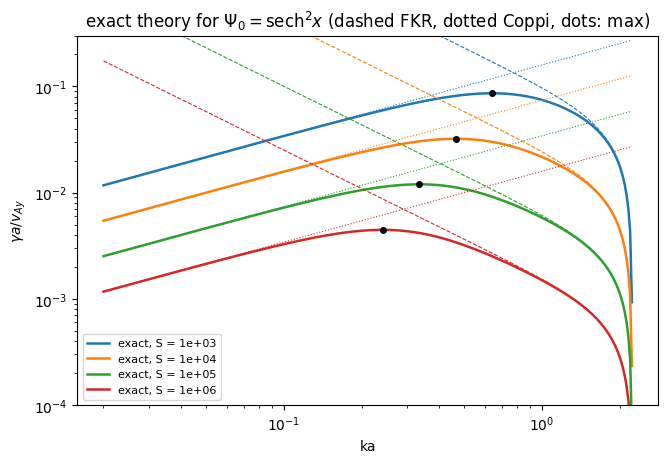

In [4]:
# the exact dispersion relation for the sech^2 sheet, with its two asymptotes
ks = np.geomspace(0.02, 2.23, 300)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for i, S in enumerate((1e3, 1e4, 1e5, 1e6)):
    g = np.array([T.gamma_theory(k, S) for k in ks])
    ax.loglog(ks, g, color=f"C{i}", lw=1.8, label=f"exact, S = {S:.0e}")
    ax.loglog(ks, T.gamma_fkr(ks, S), color=f"C{i}", ls="--", lw=0.8)
    ax.loglog(ks, T.gamma_coppi(ks, S), color=f"C{i}", ls=":", lw=0.8)
    km, gm = T.theory_max(S)
    ax.plot(km, gm, "ko", ms=4)
ax.set_ylim(1e-4, 0.3); ax.set_xlabel("ka"); ax.set_ylabel(r"$\gamma a/v_{Ay}$")
ax.set_title(r"exact theory for $\Psi_0=\mathrm{sech}^2x$ (dashed FKR, dotted Coppi, dots: max)")
ax.legend(fontsize=8); plt.show()

### 3. The eigenproblem: box size, and which mode is the fastest

**Box.** In the outer region $\psi\sim e^{-\sqrt{k^2+4}\,|x|}$ decays fast, but the flow
$\phi$ reaches into the region where $B_y$ is exponentially small, where it obeys
$\nabla^2\phi\approx0$ and decays only like $e^{-k|x|}$. The table measures the converged
$\gamma$ against $L_x$ at $S=10^3$ (each entry itself converged in $n_x$): the error falls
like $e^{-kL_x}$ (a factor $\approx e^{-3}$ per $\Delta(kL_x)=3$), and $L_x=15/k$ is at or below
$1.2\times10^{-7}$ relative everywhere -- the rule rung 0 adopted, used throughout (with a floor
$L_x\ge20$, i.e. $kL_x\ge20$ for $ka\ge0.75$). This is also the periodic-image correction the
plan asks for: measured, not derived, and below every other error in the notebook.

**Fastest mode.** The dense spectrum of the whole block at $S=10^3$ (and every $ka$) is
listed next: the tearing mode is the largest-$\mathrm{Re}\,\lambda$ eigenvalue everywhere,
and apart from it only the oscillatory pair of §10 (at $ka=0.1$, hence `#Re>0` = 3 there) has
$\mathrm{Re}\,\lambda>0$.
The remaining top eigenvalues are the $\nu=0$ near-zero cluster CLAUDE.md warns about (an
undamped $\phi$ continuum where $B_y\to0$), at round-off.

In [5]:
LXR = T.lx_results()
print("  ka      Lx      nx(final)       gamma (converged)      rel. to largest Lx")
for ka, rows in LXR.items():
    gref = rows[-1][1]["value"].real
    for Lx, r in rows:
        print(f"  {ka:4.1f}  {Lx:6.1f}   {r['nx'][-1]:6d}    {r['value'].real:.12f}    "
              f"{abs(r['value'].real/gref - 1):.1e}   (kLx = {ka*Lx:.0f})")

  ka      Lx      nx(final)       gamma (converged)      rel. to largest Lx
   0.1    60.0     4096    0.030205593372    5.6e-05   (kLx = 6)
   0.1    90.0     4096    0.030207193070    2.8e-06   (kLx = 9)
   0.1   120.0     4096    0.030207272460    1.4e-07   (kLx = 12)
   0.1   150.0     4096    0.030207276412    6.9e-09   (kLx = 15)
   0.1   200.0     8192    0.030207276617    4.6e-11   (kLx = 20)
   0.1   300.0     8192    0.030207276619    0.0e+00   (kLx = 30)
   0.3    20.0     2048    0.061798320594    2.0e-04   (kLx = 6)
   0.3    30.0     2048    0.061809953642    9.8e-06   (kLx = 9)
   0.3    40.0     2048    0.061810529006    4.9e-07   (kLx = 12)
   0.3    50.0     4096    0.061810557642    2.4e-08   (kLx = 15)
   0.3    66.7     4096    0.061810559133    1.6e-10   (kLx = 20)
   0.3   100.0     4096    0.061810559143    0.0e+00   (kLx = 30)
   1.0    10.0     2048    0.067932288229    1.7e-05   (kLx = 10)
   1.0    12.0     2048    0.067933278199    2.3e-06   (kLx = 12)
   1

In [6]:
print("  ka     Lx    nx   block n   #Re>0   top eigenvalues by Re (dense, S = 1e3)")
for ka in T.KA_MAIN:
    Lx = T.lx_for(ka)
    d = T.cached("dense", "sech2", 1e3, ka, T._nx_dense(Lx), Lx)
    v = d["values"]
    print(f"  {ka:4.1f}  {Lx:5.1f}  {d['nx']:5d}  {d['n']:6d}   {int(d['n_pos']):3d}    "
          + "  ".join(f"{z.real:+.3e}{z.imag:+.3e}i" for z in v[:3])
          + f"   (max residual {np.max(d['residuals'][:3]):.0e})")

  ka     Lx    nx   block n   #Re>0   top eigenvalues by Re (dense, S = 1e3)
   0.1  150.0   2048    2530     3    +3.021e-02+6.070e-18i  +6.809e-04+2.029e-02i  +6.809e-04-2.029e-02i   (max residual 2e-15)
   0.2   75.0   2048    2530     1    +4.850e-02-3.737e-16i  +1.037e-15-1.153e-16i  +9.904e-16-1.617e-16i   (max residual 2e-15)
   0.3   50.0   2048    2530     1    +6.181e-02+2.502e-16i  +2.190e-15-8.595e-16i  +2.137e-15+2.714e-16i   (max residual 2e-15)
   0.5   30.0   1024    1266     1    +7.669e-02-3.393e-16i  +7.552e-16+1.263e-16i  +7.443e-16-2.821e-16i   (max residual 2e-15)
   0.7   21.4   1024    1266     1    +7.882e-02+6.528e-16i  +5.533e-16+9.684e-17i  +4.735e-16-2.253e-17i   (max residual 1e-15)
   1.0   20.0   1024    1266     1    +6.793e-02-2.645e-16i  +4.813e-16+1.858e-16i  +3.727e-16-4.019e-17i   (max residual 2e-15)
   1.5   20.0   1024    1266     1    +4.010e-02-3.159e-16i  +2.176e-16-3.701e-18i  +1.613e-16-8.543e-17i   (max residual 2e-15)
   2.0   20.0   1024

### 4. $\gamma_{eig}/\gamma_{theory}\to1$ as $S\to\infty$

For every $(ka,S)$: the converged eigenvalue, its $n_x$ ladder, the convergence error
(last change in the ladder), the relative residual, the exact-theory $\gamma$ and the ratio.
$S$ runs to $10^6$, as far as the uniform grid affords at $n_x\le32768$ (the ladder stops a
$ka$ once the cap is reached unconverged). The theory is asymptotic in $\delta/a\to0$, so the
comparison is a **trend**: the table's last column, and the fitted correction exponent
$1-\gamma_{eig}/\gamma_{th}\propto S^{-p}$ below it.

In [7]:
MAIN = T.main_results()
print("  ka       S      nx ladder                  gamma_eig          conv.err  resid     "
      "gamma_theory     ratio")
ratio = {}
for ka, fam in MAIN.items():
    for S, r in sorted(fam.items()):
        gth = T.gamma_theory(ka, S)
        g = r["value"].real
        ratio[(ka, S)] = g/gth
        flag = "" if r["converged"] else "  NOT CONVERGED"
        print(f"  {ka:4.1f}  {S:7.0e}  {str(r['nx']):26s} {g:.10e}  {r['err']/abs(r['value']):.0e}   "
              f"{r['rec']['rel_residual']:.0e}   {gth:.10e}  {g/gth:.6f}{flag}")

  ka       S      nx ladder                  gamma_eig          conv.err  resid     gamma_theory     ratio
   0.1    1e+03  [2048, 4096]               3.0207276412e-02  1e-09   6e-13   3.4042537252e-02  0.887339
   0.1    1e+04  [2048, 4096, 8192]         1.5250322769e-02  3e-10   1e-13   1.5717669784e-02  0.970266
   0.1    1e+05  [4096, 8192, 16384]        7.1556296787e-03  1e-09   2e-14   7.2130930658e-03  0.992033
   0.1    1e+06  [8192, 16384, 32768]       3.2602195345e-03  1e-08   2e-13   3.2678880558e-03  0.997653
   0.2    1e+03  [2048, 4096]               4.8496188735e-02  2e-15   8e-13   5.3050533101e-02  0.914151
   0.2    1e+04  [2048, 4096, 8192]         2.3389605656e-02  1e-13   7e-15   2.3985770471e-02  0.975145
   0.2    1e+05  [4096, 8192, 16384]        1.0455832776e-02  1e-14   9e-15   1.0535545554e-02  0.992434
   0.2    1e+06  [8192, 16384, 32768]       4.3606136241e-03  9e-14   2e-13   4.3708377025e-03  0.997661
   0.3    1e+03  [2048, 4096]               6.1810557

finite-S correction: 1 - gamma_eig/gamma_th = A S^-p  (least squares over the S points)
  ka = 0.1: p = 0.562   local slopes [0.579 0.572 0.531]   (1 - ratio) * gamma_th/(eta kappa^2) = [0.96 1.17 1.43 1.91]
  ka = 0.2: p = 0.521   local slopes [0.538 0.517 0.51 ]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.13 1.48 1.97 2.53]
  ka = 0.3: p = 0.523   local slopes [0.513 0.51  0.51  0.519 0.538 0.561]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.29 1.49 1.73 1.95 2.15 2.24 2.2 ]
  ka = 0.5: p = 0.521   local slopes [0.51  0.537 0.512]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.49 1.77 1.73 1.58]
  ka = 0.7: p = 0.482   local slopes [0.51  0.491 0.442]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.47 1.53 1.46 1.42]
  ka = 1.0: p = 0.435   local slopes [0.472 0.458 0.44  0.425 0.415 0.409]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.29 1.29 1.28 1.28 1.28 1.27 1.28]
  ka = 1.5: p = 0.407   local slopes [0.414 0.406 0.402]   (1 - ratio) * gamma_th/(eta kappa^2) = [1.01 1.02 1.02 1.02]
  ka =

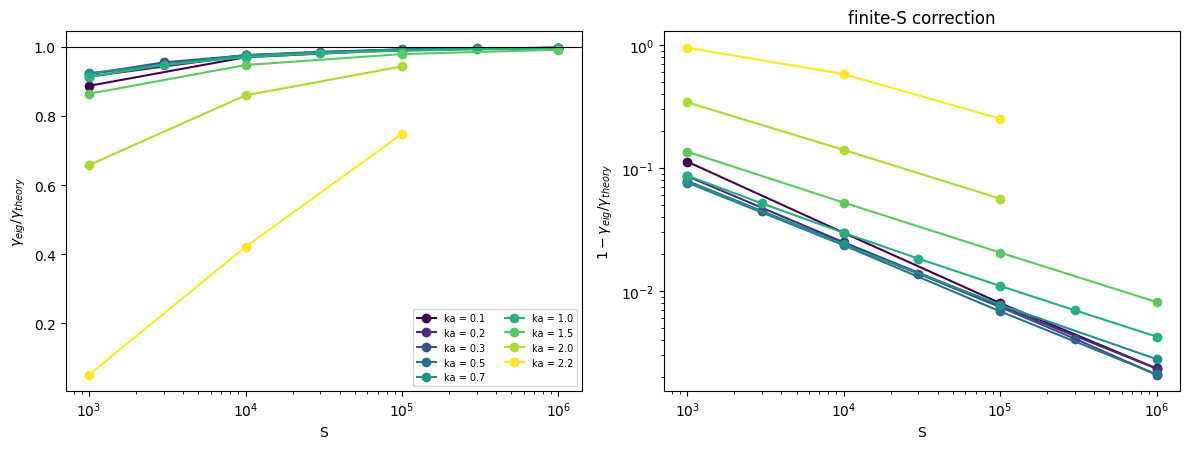

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
print("finite-S correction: 1 - gamma_eig/gamma_th = A S^-p  (least squares over the S points)")
PFIT = {}
for i, ka in enumerate(T.KA_MAIN):
    Ss = np.array(sorted(S for S in MAIN[ka] if MAIN[ka][S]["converged"]))
    r = np.array([ratio[(ka, S)] for S in Ss])
    a1.semilogx(Ss, r, "o-", color=plt.cm.viridis(i/8), label=f"ka = {ka}")
    dev = 1 - r
    if len(Ss) >= 3 and np.all(dev > 0):
        p, lnA = np.polyfit(np.log(Ss), np.log(dev), 1)
        loc = -np.diff(np.log(dev))/np.diff(np.log(Ss))
        PFIT[ka] = (-p, loc)
        a2.loglog(Ss, dev, "o-", color=plt.cm.viridis(i/8))
        x = np.array([T.gamma_theory(ka, S)*S/(ka**2 + 4) for S in Ss])
        print(f"  ka = {ka:3.1f}: p = {-p:.3f}   local slopes {np.round(loc, 3)}   "
              f"(1 - ratio) * gamma_th/(eta kappa^2) = {np.round(dev*x, 2)}")
    else:
        print(f"  ka = {ka:3.1f}: 1 - ratio = {np.round(dev, 4)} (sign change or < 3 points: no fit)")
a1.axhline(1, color="k", lw=0.8); a1.set_xlabel("S"); a1.set_ylabel(r"$\gamma_{eig}/\gamma_{theory}$")
a1.legend(fontsize=7, ncol=2); a2.set_xlabel("S"); a2.set_ylabel(r"$1-\gamma_{eig}/\gamma_{theory}$")
a2.set_title("finite-S correction"); plt.tight_layout(); plt.show()

**Result.** Every ratio climbs monotonically to 1: at $S=10^6$ it is 0.9977-0.9979 for
$ka\le0.5$, 0.9972 at 0.7, 0.9957 at 1.0, 0.9919 at 1.5, 0.978 at 2.0 and 0.90 at 2.2 (the last
two limited by the $n_x=32768$ cap -- flagged -- and by the marginal band of §6). The residuals
are $10^{-15}$-$10^{-10}$ and the grid errors $\le10^{-8}$ except where flagged.

**The finite-$S$ correction.** The fitted exponent $p$ of $1-\gamma_{eig}/\gamma_{th}\propto
S^{-p}$ runs from 0.56 ($ka=0.1$) to 0.39 ($ka=2.0$) -- it is not one number, and the right
variable is not $S$. The last column shows what it is: $(1-\gamma_{eig}/\gamma_{th})\times
\gamma_{th}/(\eta\kappa^2)$, with $\kappa^2=k^2+4$ the outer eigenfunction's decay rate squared,
is **constant** over three decades of $S$ in the constant-$\psi$ range -- $1.28\pm0.01$ at
$ka=1$, $1.02$ at 1.5, $0.78$ at 2.0 -- i.e.
$$1-\frac{\gamma_{eig}}{\gamma_{th}}\simeq C(k)\,\frac{\eta\kappa^2}{\gamma_{th}}
=\frac{C(k)}{\gamma_{th}\tau_R},\qquad \tau_R=\frac{1}{\eta\kappa^2},$$
the inverse of the ordering parameter $\gamma\tau_R\gg1$ that the ideal outer region of FKR and
Coppi assumes (resistive diffusion of the outer eigenfunction slower than the growth). In the
constant-$\psi$ regime $\gamma\propto S^{-3/5}$ makes this $S^{-2/5}$ -- measured 0.39-0.41 at
$ka=1.5$-2. In the nonconstant-$\psi$ regime ($ka\le0.3$, $\Delta'\delta_\eta=2$-260) the
product rises slowly with $S$ (1.0 $\to$ 2.5): a second correction, decaying more slowly than
$1/(\gamma\tau_R)$, is present there and is not identified here. §6 shows the same parameter
controls the approach to marginality.

### 5. The fastest-growing mode: $\gamma_{max}(S)$, $k_{max}(S)$

At each $S$ the eigenvalue is computed at five $ka$ spread around the theory's $k_{max}$
(factors 0.7-1.4) and the peak is located by a quadratic in $\ln k$ through the three largest
(error bar: the spread against a cubic through all five). **The same fit applied to the
theory at the same five $ka$** is printed next to it, so the fitting procedure's own bias is
visible, and the theory's true maximum (bounded maximization of the exact relation) beside
that.

**Which exponents.** For $\Delta'\propto(ka)^{-n}$ the FKR/Coppi crossover gives
$k_{max}\propto S^{-1/(3n+1)}$, $\gamma_{max}\propto S^{-(n+1)/(3n+1)}$. The Harris sheet
($n=1$) has the familiar $-1/4$, $-1/2$; **this sech$^2$ sheet has $n=2$**
($\Delta'a\to15/(ka)^2$), so its asymptotic exponents are $-1/7$ and $-3/7$ (B&L 2018 eqs.
66-67 for their $n=2$ sine profile; MESJ 2025 eq. 5.12-5.13 at $\alpha\to0$). The measured
exponents are compared with those, and with the exact relation's own local exponents over the
same $S$ range (the asymptotic values are approached slowly).

In [9]:
MAX = T.max_results()
print("     S      k_max(eig)          gamma_max(eig)        | same fit on theory     | theory true max")
KM, GM = [], []
for S, rows in MAX.items():
    kas = np.array([k for k, _ in rows]); gs = np.array([r["value"].real for _, r in rows])
    km, gm, dk, dg = T.peak_fit(kas, gs)
    gth = np.array([T.gamma_theory(k, S) for k in kas])
    kmt, gmt, _, _ = T.peak_fit(kas, gth)
    k0, g0 = T.theory_max(S)
    KM.append((S, km, dk, kmt, k0)); GM.append((S, gm, dg, gmt, g0))
    print(f"  {S:7.0e}  {km:.4f} +- {dk:.1e}   {gm:.6e} +- {dg:.0e}  | {kmt:.4f}  {gmt:.6e} | "
          f"{k0:.4f}  {g0:.6e}   ratio gamma_max {gm/g0:.4f}")
KM, GM = np.array(KM), np.array(GM)
S_ = KM[:, 0]
for name, arr in (("k_max", KM), ("gamma_max", GM)):
    pe = np.polyfit(np.log(S_), np.log(arr[:, 1]), 1)[0]
    pt = np.polyfit(np.log(S_), np.log(arr[:, 4]), 1)[0]
    loc_e = np.diff(np.log(arr[:, 1]))/np.diff(np.log(S_))
    loc_t = np.diff(np.log(arr[:, 4]))/np.diff(np.log(S_))
    print(f"\n{name}: fitted exponent eig {pe:.4f}, exact-theory max {pt:.4f} "
          f"(asymptotic {'-1/7 = -0.1429' if name == 'k_max' else '-3/7 = -0.4286'}; "
          f"n=1 would be {'-1/4' if name == 'k_max' else '-1/2'})")
    print(f"   local exponents per decade: eig {np.round(loc_e, 4)}, theory {np.round(loc_t, 4)}")

     S      k_max(eig)          gamma_max(eig)        | same fit on theory     | theory true max
    1e+03  0.6338 +- 3.4e-03   7.928129e-02 +- 3e-05  | 0.6371  8.586853e-02 | 0.6407  8.586685e-02   ratio gamma_max 0.9233
    1e+04  0.4633 +- 2.1e-03   3.129909e-02 +- 1e-05  | 0.4627  3.205790e-02 | 0.4648  3.205750e-02   ratio gamma_max 0.9763
    1e+05  0.3341 +- 1.3e-03   1.186683e-02 +- 5e-06  | 0.3337  1.195372e-02 | 0.3352  1.195359e-02   ratio gamma_max 0.9927
    1e+06  0.2404 +- 9.3e-04   4.445961e-03 +- 2e-06  | 0.2403  4.455977e-03 | 0.2413  4.455931e-03   ratio gamma_max 0.9978

k_max: fitted exponent eig -0.1405, exact-theory max -0.1414 (asymptotic -1/7 = -0.1429; n=1 would be -1/4)
   local exponents per decade: eig [-0.1361 -0.142  -0.1429], theory [-0.1394 -0.142  -0.1427]

gamma_max: fitted exponent eig -0.4175, exact-theory max -0.4283 (asymptotic -3/7 = -0.4286; n=1 would be -1/2)
   local exponents per decade: eig [-0.4036 -0.4212 -0.4264], theory [-0.4279 -0.4284 

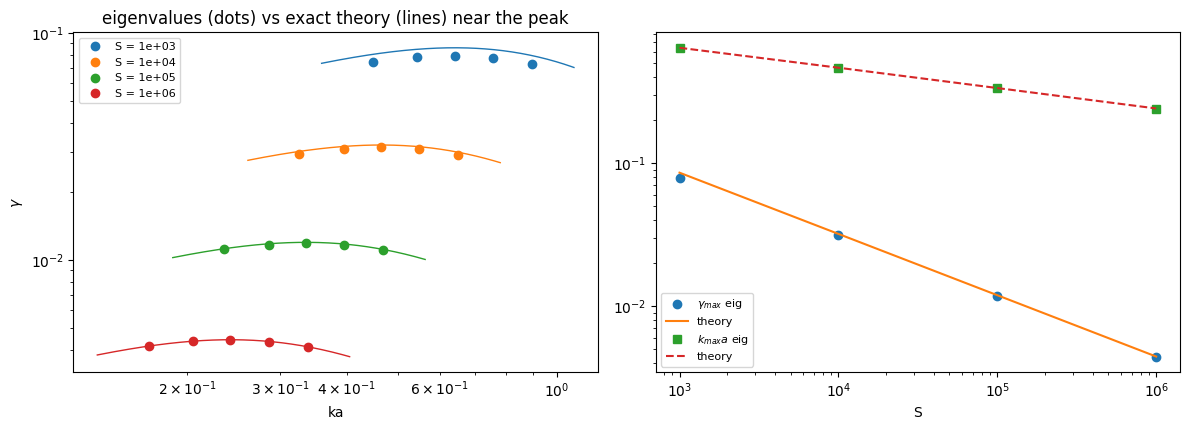

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for S, rows in MAX.items():
    kas = np.array([k for k, _ in rows]); gs = np.array([r["value"].real for _, r in rows])
    kk = np.geomspace(kas[0]*0.8, kas[-1]*1.2, 200)
    l, = ax[0].loglog(kk, [T.gamma_theory(k, S) for k in kk], lw=1)
    ax[0].loglog(kas, gs, "o", color=l.get_color(), label=f"S = {S:.0e}")
ax[0].set_xlabel("ka"); ax[0].set_ylabel(r"$\gamma$"); ax[0].legend(fontsize=8)
ax[0].set_title("eigenvalues (dots) vs exact theory (lines) near the peak")
ax[1].loglog(S_, GM[:, 1], "o", label=r"$\gamma_{max}$ eig"); ax[1].loglog(S_, GM[:, 4], "-", label="theory")
ax[1].loglog(S_, KM[:, 1], "s", label=r"$k_{max}a$ eig"); ax[1].loglog(S_, KM[:, 4], "--", label="theory")
ax[1].set_xlabel("S"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Result.** $\gamma_{max}^{eig}/\gamma_{max}^{th}$ = 0.923, 0.976, 0.993, 0.998 at
$S=10^3$-$10^6$ -- the §4 correction at the peak. $k_{max}$ agrees with the theory's true
maximum to 1.1, 0.3, 0.3, 0.4 % -- the same size as the five-point fit's own bias on the
theory (0.6, 0.5, 0.4, 0.4 %), so $k_{max}$ is fit-limited, not physics-limited. Exponents over
$10^3$-$10^6$: $k_{max}\propto S^{-0.1405}$ (theory max: $-0.1414$; asymptotic $-1/7=-0.1429$),
$\gamma_{max}\propto S^{-0.4175}$ (theory: $-0.4283$; asymptotic $-3/7=-0.4286$), with the
local $\gamma_{max}$ exponent per decade $-0.404\to-0.421\to-0.426$ converging onto $-3/7$ as
the §4 correction dies. **The $-1/2$, $-1/4$ of the plan's target list are the $n=1$ (Harris)
exponents; this $n=2$ sheet has $-3/7$, $-1/7$**, and the exact relation already sits on them
at $S\ge10^3$.

### 6. The ideal marginal point $ka=\sqrt5$

$\Delta'$ changes sign at exactly $ka=\sqrt5=2.23607$. The tearing branch is followed on a fine
$ka$ grid below it at $S=10^3,10^4,10^5$, every point converged in $n_x$ where the $n_x\le32768$
grid allows (`*` = not converged to $10^{-7}$: the last relative change in its ladder is
printed in brackets; the analysis below uses points converged to $10^{-4}$), and the dense
spectra just above $\sqrt5$ are checked for any growing eigenvalue.

In [11]:
MARG = T.marginal_results()
MS = MARG["sech2"]
good = lambda r: r is not None and r["ok"] and r["err"] <= 1e-4*abs(r["value"])   # converged to 1e-4
print("   ka      Delta'a " + "".join(f"|  S = {S:.0e}: gamma      (err)    ratio   " for S in T.S_MARG))
for ka in T.KA_MARG:
    line = f"  {ka:.3f}  {T.dprime_sech2(ka):7.4f} "
    for S in T.S_MARG:
        r = MS[ka].get(S)
        if r is None or not r["ok"]:
            line += "|        --                          "
            continue
        g = r["value"].real
        line += (f"|  {g:.4e}{' ' if r['converged'] else '*'} ({r['err']/abs(r['value']):.0e})  "
                 f"{g/T.gamma_theory(ka, S):7.4f}  ")
    print(line)
print("\nabove sqrt 5 (dense spectra, nx = 2048, Lx = 20): largest Re(lambda) and the ||J|| scale")
for (S, ka), d in MARG["above"].items():
    print(f"   S = {S:.0e}, ka = {ka}: max Re = {d['values'][0].real:+.2e}  (scale {d['scale']:.1e}; "
          f"#Re > 1e-10 scale: {int(d['n_pos'])})")

   ka      Delta'a |  S = 1e+03: gamma      (err)    ratio   |  S = 1e+04: gamma      (err)    ratio   |  S = 1e+05: gamma      (err)    ratio   
  2.100   0.6837 |  5.5149e-03  (1e-11)   0.4881  |  2.2279e-03  (5e-10)   0.7823  |  6.5309e-04  (8e-10)   0.9117  
  2.150   0.4240 |  2.4370e-03  (3e-08)   0.3123  |  1.3544e-03  (4e-08)   0.6898  |  4.3071e-04  (1e-09)   0.8726  
  2.180   0.2730 |  8.4275e-04  (5e-11)   0.1525  |  7.9650e-04  (5e-10)   0.5733  |  2.8674e-04  (2e-09)   0.8213  
  2.200   0.1743 |  1.9430e-04  (1e-08)   0.0501  |  4.0969e-04  (1e-09)   0.4205  |  1.8316e-04  (1e-10)   0.7483  
  2.210   0.1255 |  5.6514e-05  (4e-09)   0.0189  |  2.2004e-04  (2e-09)   0.2932  |  1.2782e-04  (6e-09)   0.6778  
  2.220   0.0771 |  8.3192e-06  (3e-08)   0.0041  |  6.1984e-05  (3e-08)   0.1217  |  6.9158e-05  (5e-08)   0.5407  
  2.225   0.0530 |  1.8744e-06  (1e-09)   0.0012  |  1.7229e-05  (1e-08)   0.0456  |  3.8707e-05* (9e-07)   0.4080  
  2.230   0.0290 |  1.6906e-07* (1e

**The zero does not move; the approach to it does.** At every $S$ the branch is converged,
real and positive through $ka=2.230$ ($\Delta'a=0.029$; ladder changes $\le10^{-4}$, $5\times10^{-4}$
at $S=10^5$), and no eigenvalue of the block grows at $ka=2.24$ or $2.26$ -- so the zero lies in
$[2.230,2.240]$, which contains $\sqrt5=2.2361$: any finite-$S$ **shift of the zero** is below
$0.006$ at $S=10^3$-$10^5$. ($ka=2.233$ and $2.235$ stay unresolved at $n_x=32768$ -- the
eigenvalue still falls ~8% and ~50% per doubling -- so their sign is not established.) What
finite $S$ does instead is **suppress the growth in a band below $\sqrt5$**: there
$\gamma_{eig}$ falls orders of magnitude below the exact theory (at $S=10^3$, $ka=2.23$:
$1.7\times10^{-7}$ against $8.5\times10^{-4}$), and the band narrows as $S$ grows. The next cell
measures it by $k_{1/2}(S)$, where $\gamma_{eig}/\gamma_{th}=\frac12$, and plots the ratio of
every converged point of §4 and §6 against $\gamma_{th}\tau_R=\gamma_{th}/(\eta\kappa^2)$.

  S       k_1/2     sqrt5 - k_1/2   Delta'a(k_1/2)   Delta'a * S^(1/2)
  1e+03   2.09694   1.39e-01       0.6999          22.134
  1e+04   2.18960   4.65e-02       0.2255          22.549
  1e+05   2.22153   1.45e-02       0.0697          22.041
sqrt5 - k_1/2 ~ S^-0.491


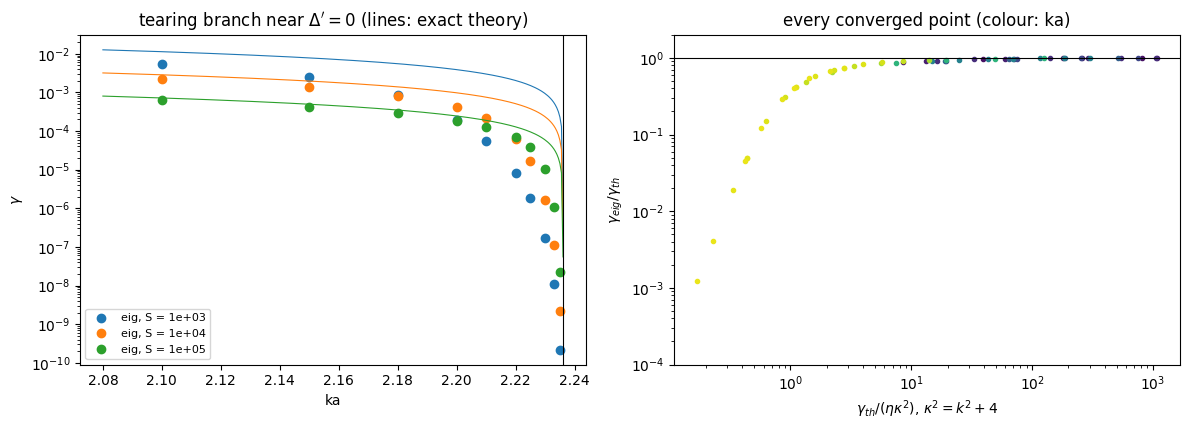

In [12]:
def k_half(S):
    kk = np.array([ka for ka in T.KA_MARG if good(MS[ka].get(S))])
    rr = np.array([MS[ka][S]["value"].real/T.gamma_theory(ka, S) for ka in kk])
    i = int(np.nonzero(rr < 0.5)[0][0])        # first point below 1/2
    t = (0.5 - rr[i-1])/(rr[i] - rr[i-1])
    return kk[i-1] + t*(kk[i] - kk[i-1])
print("  S       k_1/2     sqrt5 - k_1/2   Delta'a(k_1/2)   Delta'a * S^(1/2)")
KH = []
for S in T.S_MARG:
    kh = k_half(S); d = T.dprime_sech2(kh); KH.append((S, T.SQRT5 - kh, d))
    print(f"  {S:.0e}   {kh:.5f}   {T.SQRT5 - kh:.2e}       {d:.4f}          {d*S**0.5:.3f}")
KH = np.array(KH)
p = np.polyfit(np.log(KH[:, 0]), np.log(KH[:, 1]), 1)[0]
print(f"sqrt5 - k_1/2 ~ S^{p:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
for i, S in enumerate(T.S_MARG):
    kk = np.array([ka for ka in T.KA_MARG if S in MS[ka] and MS[ka][S]["ok"]])
    gg = np.array([MS[ka][S]["value"].real for ka in kk])
    a1.semilogy(kk, gg, "o", color=f"C{i}", label=f"eig, S = {S:.0e}")
    kt = np.linspace(2.08, T.SQRT5 - 1e-6, 300)
    a1.semilogy(kt, [T.gamma_theory(k, S) for k in kt], color=f"C{i}", lw=0.8)
a1.axvline(T.SQRT5, color="k", lw=0.8); a1.set_xlabel("ka"); a1.set_ylabel(r"$\gamma$")
a1.legend(fontsize=8); a1.set_title("tearing branch near $\\Delta'=0$ (lines: exact theory)")
pts = [(ka, S, r["value"].real) for ka, fam in MAIN.items() for S, r in fam.items() if r["converged"]]
pts += [(ka, S, r["value"].real) for ka, fam in MS.items() for S, r in fam.items() if good(r)]
for ka, S, g in pts:
    gt = T.gamma_theory(ka, S)
    a2.loglog(gt*S/(ka**2 + 4), g/gt, ".", color=plt.cm.viridis(min(ka/2.3, 1)))
a2.axhline(1, color="k", lw=0.8); a2.set_xlabel(r"$\gamma_{th}/(\eta\kappa^2)$, $\kappa^2=k^2+4$")
a2.set_ylabel(r"$\gamma_{eig}/\gamma_{th}$"); a2.set_ylim(1e-4, 2)
a2.set_title("every converged point (colour: ka)"); plt.tight_layout(); plt.show()

**Result.** $\sqrt5-k_{1/2}=0.139,\ 0.047,\ 0.0145$ at $S=10^3,10^4,10^5$, i.e. $\propto
S^{-0.49}$, and $\Delta'a$ at $k_{1/2}$ times $S^{1/2}$ is **constant, $22.1$-$22.5$**: the
suppression band is $\Delta'a\lesssim22\,S^{-1/2}$. That is exactly where the FKR growth rate
drops to the outer diffusion rate ($\gamma_{FKR}\propto\Delta'^{4/5}S^{-3/5}\sim\eta\kappa^2
\Leftrightarrow\Delta'\sim S^{-1/2}$), and the right panel shows every converged eigenvalue of
§4 and §6 -- 19 $ka$ values, $S=10^3$-$10^6$, $\gamma_{eig}/\gamma_{th}$ from $10^{-3}$ to 0.998 --
falling on essentially one curve of $\gamma_{th}\tau_R$ (ratio $\frac12$ at
$\gamma_{th}\tau_R\approx1.3$, 0.9 at $\approx10$, 0.99 at $\approx100$-$300$). So the
"finite-$S$ shift of the marginal point" of the plan is, for this frozen, inviscid equilibrium, a
finite-$S$ **band** $\Delta'a\lesssim22S^{-1/2}$ of suppressed growth whose width
$\propto S^{-1/2}$, with the zero itself fixed at $\Delta'=0$.

**A second equilibrium does the same.** The $\cos x$ sheet pair of the time-domain notebooks
($\Delta'=0$ at $k=1$) is followed the same way: its branch too stays positive up to $k=0.998$
at every $S$, falling steeply as $k\to1$ ($S=10^3$: $4.1\times10^{-5}$ at $0.995$,
$1.2\times10^{-6}$ at $0.998$). **Why `tearing-growth-vs-k`'s $m=8$ mode ($k=1$) decays at
$-\eta k^2$ anyway:** its seed $\epsilon\cos(ky)$ is itself an *exact* eigenmode of the $\cos x$
problem at $k=1$ -- $\psi=e^{iky}$, $\phi=0$, $\lambda=-\eta k^2$, because
$\{\psi_0,\nabla^2\psi\}+\{\psi,\nabla^2\psi_0\}=ik(k^2-1)\sin x\,e^{iky}$ vanishes at $k=1$
($\cos x$ is a Laplacian eigenfunction) -- one member of a dense set of real, resistively damped
eigenvalues around $-\eta$ (spacing $\approx0.007\eta$ at $n_x=2048$, $S=10^3$). The harness
reproduces it exactly (the analytic eigenvector applied to the matrix-free block, below); it is
not the tearing branch, and says nothing about where that branch vanishes.

In [13]:
MC = MARG["cosx"]
for S in T.S_MARG:
    ks_ok = [k for k in T.COSX_KMARG if (S, k) in MC and MC[(S, k)]["ok"]]
    row = "  ".join(f"{k}: {MC[(S, k)]['value'].real:.3e}{'' if MC[(S, k)]['converged'] else '*'}"
                    for k in ks_ok)
    lam, res = T.cosx_exact_mode(S)
    print(f"S = {S:.0e}  cos x branch:  {row}")
    print(f"          k = 1, psi = e^(iky), phi = 0:  (e, J e) = {lam.real:+.6e}  "
          f"(-eta k^2 = {-1/S:+.6e}),  ||J e - lambda e|| = {res:.1e}")
print("tearing-growth-vs-k, m = 8 (k = 1, eta = 1e-3): measured -0.00099 +- 0.00002")

S = 1e+03  cos x branch:  0.97: 1.555e-03  0.98: 9.278e-04  0.99: 2.863e-04  0.995: 4.123e-05  0.998: 1.226e-06
          k = 1, psi = e^(iky), phi = 0:  (e, J e) = -1.000000e-03  (-eta k^2 = -1.000000e-03),  ||J e - lambda e|| = 3.4e-14
S = 1e+04  cos x branch:  0.97: 5.037e-04  0.98: 3.409e-04  0.99: 1.633e-04  0.995: 6.516e-05  0.998: 8.795e-06
          k = 1, psi = e^(iky), phi = 0:  (e, J e) = -1.000000e-04  (-eta k^2 = -1.000000e-04),  ||J e - lambda e|| = 3.4e-14
S = 1e+05  cos x branch:  0.97: 1.384e-04  0.98: 9.732e-05  0.99: 5.227e-05  0.995: 2.671e-05  0.998: 9.155e-06
          k = 1, psi = e^(iky), phi = 0:  (e, J e) = -1.000000e-05  (-eta k^2 = -1.000000e-05),  ||J e - lambda e|| = 3.4e-14
tearing-growth-vs-k, m = 8 (k = 1, eta = 1e-3): measured -0.00099 +- 0.00002


### 7. The inner layer: eigenfunction width against the theory's $\delta_{in}$

The width is measured as in the paper (MESJ 2025 §7): the full width of the region around the
sheet where $\mathrm{Re}\,\psi''\ge\max/4$ (eigenvector phase-normalized so $\psi$ is real at
the sheet). The *theory* width is measured the same way on the **exact inner solution** of §2
at the same $(k,S)$ -- a like-for-like comparison with no order-unity constant left
undetermined. The two asymptotic scalings -- constant-$\psi$ (FKR, B&L eq. 58)
$\delta=(\gamma\eta/(k f')^2)^{1/4}$ and nonconstant-$\psi$ (Coppi, B&L eq. 68)
$\delta=\gamma/(kf')$ -- are listed for orientation.

In [14]:
print("  ka       S     width(eig)   width(exact inner)   ratio   | delta_FKR  delta_Coppi  "
      "Delta' delta_eta")
WID = {}
for ka in T.KA_MAIN:
    for S, r in sorted(MAIN[ka].items()):
        if not r["converged"] or ka > 2.0:
            continue
        w = float(r["rec"]["width"]); g = r["value"].real
        wt = T.theory_width(ka, S)
        WID[(ka, S)] = (w, wt)
        print(f"  {ka:4.1f}  {S:7.0e}   {w:.5f}      {wt:.5f}          {w/wt:6.3f}   | "
              f"{T.delta_fkr(g, ka, S):.5f}    {T.delta_coppi(g, ka):.5f}      "
              f"{T.dprime_sech2(ka)*(1/S/(2*ka))**(1/3):8.3f}")

  ka       S     width(eig)   width(exact inner)   ratio   | delta_FKR  delta_Coppi  Delta' delta_eta
   0.1    1e+03   0.39330      0.56835           0.692   | 0.16577    0.15104       256.516
   0.1    1e+04   0.23451      0.26321           0.891   | 0.07858    0.07625       119.064
   0.1    1e+05   0.11852      0.12159           0.975   | 0.03657    0.03578        55.265
   0.1    1e+06   0.05556      0.05587           0.995   | 0.01690    0.01630        25.652
   0.2    1e+03   0.34070      0.44760           0.761   | 0.13195    0.12124        50.907
   0.2    1e+04   0.18970      0.20550           0.923   | 0.06183    0.05847        23.629
   0.2    1e+05   0.09142      0.09326           0.980   | 0.02843    0.02614        10.968
   0.2    1e+06   0.04124      0.04143           0.995   | 0.01285    0.01090         5.091
   0.3    1e+03   0.30702      0.38525           0.797   | 0.11447    0.10302        19.766
   0.3    3e+03   0.23276      0.26437           0.880   | 0.07958    

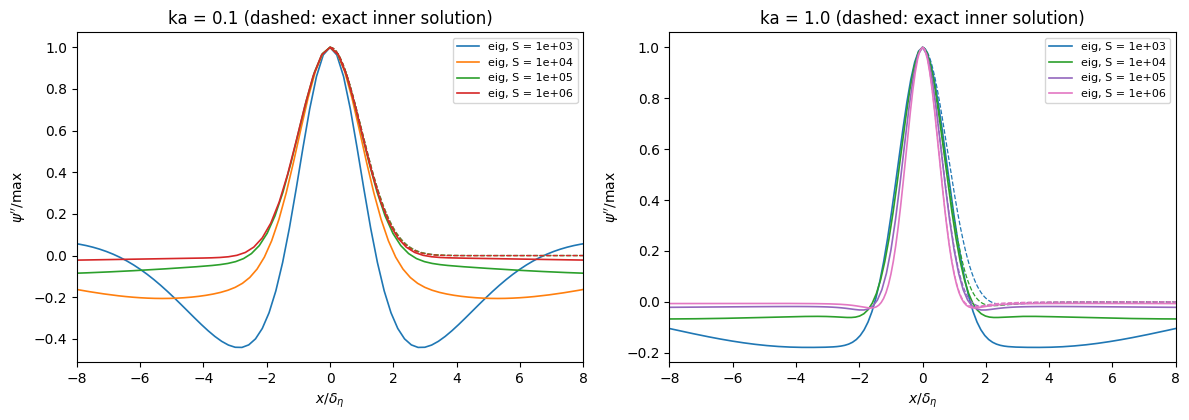

In [15]:
# eigenfunction vs the exact inner solution, in layer units s = x/delta_eta
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, ka in zip(axs, (0.1, 1.0)):
    for i, S in enumerate(sorted(MAIN[ka])):
        r = MAIN[ka][S]
        if not r["converged"] or S not in (1e3, 1e4, 1e5, 1e6):
            continue
        de = (1/S/(2*ka))**(1/3)
        xn, d2 = r["rec"]["xn"], np.real(r["rec"]["d2n"])
        ax.plot(xn/de, d2/d2.max(), color=f"C{i}", lw=1.2, label=f"eig, S = {S:.0e}")
        Q = T.gamma_theory(ka, S)/((1/S)**(1/3)*(2*ka)**(2/3))
        s, _, d2t = T.inner_profile(Q)
        ax.plot(s, d2t/d2t[0], color=f"C{i}", ls="--", lw=0.9)
    ax.set_xlim(-8, 8); ax.set_xlabel(r"$x/\delta_\eta$"); ax.set_ylabel(r"$\psi''/\max$")
    ax.set_title(f"ka = {ka} (dashed: exact inner solution)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Result.** The measured width converges onto the exact inner solution's in both regimes: the
ratio is 0.69-0.87 at $S=10^3$ and 0.994-1.000 at $S=10^6$ for every $ka\le1.5$ (0.953 at
$ka=2$, $S=10^5$). Deep in the nonconstant-$\psi$ regime ($ka=0.1$, $\Delta'\delta_\eta$ = 26-257)
the width follows the Coppi scale, $\approx3.4\,\gamma/(kf')$ at $S=10^6$ (local slope
$-0.28$ per decade in $S$, approaching $-1/3$); in the constant-$\psi$ regime ($ka=1.5$,
$\Delta'\delta_\eta$ = 0.04-0.36) it follows the FKR scale, $\approx2.9\,(\gamma\eta/(kf')^2)^{1/4}$
(slope $-0.377$, approaching $-2/5$). The eigenfunction panels show the whole $\psi''$ profile,
not just its width, collapsing onto the exact inner solution in layer units.

### 8. Cross-checks

**(a) Alfred's Julia eigencode** (`tests/data/shear_tearing_reference.npz`, the MESJ 2025 code:
2nd-order FD on a stretched grid, Robin outer boundary). Its `gamma` is the base-grid value
and `gamma_err` a RELATIVE error bar from its own convergence study, including a
2nd-order Richardson step whose extrapolated value is `gamma_richardson`. Every $\alpha=0$,
sech$^2$ point overlaps the grid above.

In [16]:
ref = np.load("../tests/data/shear_tearing_reference.npz")
sel = np.nonzero((ref["whichf"] == 2) & (ref["alpha"] == 0.0))[0]
print("     S     ka     gamma taranis     Julia Richardson   rel.diff  | Julia base grid  rel.diff | "
      "Julia rel. err")
worst = 0.0
for i in sel:
    S, ka = float(ref["S"][i]), float(ref["ka"][i])
    g = MAIN[ka][S]["value"].real
    gr, gb, e = (complex(ref["gamma_richardson"][i]).real, complex(ref["gamma"][i]).real,
                 float(ref["gamma_err"][i]))
    worst = max(worst, abs(g/gr - 1))
    print(f"  {S:7.0e}  {ka:4.1f}   {g:.10f}   {gr:.10f}   {abs(g/gr - 1):.1e}   | {gb:.10f}  "
          f"{abs(g/gb - 1):.1e} |  {e:.1e}")
print(f"worst relative difference from the Julia Richardson values: {worst:.1e}")

     S     ka     gamma taranis     Julia Richardson   rel.diff  | Julia base grid  rel.diff | Julia rel. err
    1e+03   0.1   0.0302072764   0.0302074558   5.9e-06   | 0.0302149686  2.5e-04 |  2.5e-04
    1e+03   0.2   0.0484961887   0.0484963740   3.8e-06   | 0.0485099536  2.8e-04 |  2.8e-04
    1e+03   0.3   0.0618105576   0.0618106766   1.9e-06   | 0.0618284088  2.9e-04 |  2.9e-04
    1e+03   0.5   0.0766927714   0.0766928504   1.0e-06   | 0.0767146449  2.9e-04 |  2.8e-04
    1e+03   0.7   0.0788236426   0.0788237145   9.1e-07   | 0.0788439892  2.6e-04 |  2.6e-04
    1e+03   1.0   0.0679334349   0.0679334774   6.3e-07   | 0.0679465443  1.9e-04 |  1.9e-04
    1e+04   0.1   0.0152503228   0.0152503879   4.3e-06   | 0.0152570875  4.4e-04 |  4.4e-04
    1e+04   0.2   0.0233896057   0.0233896798   3.2e-06   | 0.0234012804  5.0e-04 |  5.0e-04
    1e+04   0.3   0.0284587773   0.0284588408   2.2e-06   | 0.0284735441  5.2e-04 |  5.2e-04
    1e+04   0.5   0.0312018073   0.0312018560   1.6e-

**(b) The time-domain tearing notebooks.** `tearing-mode-2D.ipynb` and
`tearing-growth-vs-k.ipynb` use a *different equilibrium*: $\psi_0=\cos x$ in $L_x=2\pi$ (two
sheets), $\eta=10^{-3}$ and the $\eta$ scan, inviscid. So the harness is run on **their**
equilibrium and parameters. Their runs do not sustain the equilibrium, which decays as
$e^{-\eta t}$ self-similarly; a fitted rate is the average over the fit window, so the
like-for-like eigenvalue is the one about the equilibrium frozen at its **mid-window
amplitude** $B'=e^{-\eta\bar t}$ ($\bar t$ from their printed fit windows). Both columns are
shown (frozen at $B'=1$ and at $B'(\bar t)$), each converged in $n_x$.

In [17]:
COSX = T.cosx_results()
print("  run              eta     k    B'(tbar)  gamma(B'=1)   gamma(B'(tbar))   measured +- sys     "
      "meas/eig(B')")
for label, eta, k, amp, g, sys_ in T.cosx_points():
    r1, r2 = COSX[label]
    s = f"{sys_:.5f}" if np.isfinite(sys_) else "  --   "
    print(f"  {label:15s}  {eta:6.0e}  {k:5.3f}  {amp:.3f}    {r1['value'].real:.5f}       "
          f"{r2['value'].real:.5f}          {g:.5f} +- {s}   {g/r2['value'].real:.3f}")

  run              eta     k    B'(tbar)  gamma(B'=1)   gamma(B'(tbar))   measured +- sys     meas/eig(B')
  gvk m=1           1e-03  0.125  0.836    0.02355       0.02088          0.02065 +- 0.00062   0.989
  gvk m=2           1e-03  0.250  0.847    0.03237       0.02919          0.02901 +- 0.00100   0.994
  gvk m=3           1e-03  0.375  0.845    0.03233       0.02942          0.02932 +- 0.00095   0.996
  gvk m=4           1e-03  0.500  0.838    0.02701       0.02473          0.02465 +- 0.00065   0.997
  gvk m=5           1e-03  0.625  0.825    0.02010       0.01839          0.01832 +- 0.00038   0.996
  gvk m=6           1e-03  0.750  0.797    0.01330       0.01202          0.01195 +- 0.00015   0.994
  gvk m=7           1e-03  0.875  0.856    0.00679       0.00632          0.00581 +- 0.00018   0.919
  tm2d eta=0.0005   5e-04  0.500  0.915    0.01891       0.01812          0.01740 +-   --      0.960
  tm2d eta=0.001    1e-03  0.500  0.879    0.02701       0.02533          0.02490 +- 

**Result.** (a) All 18 overlapping points agree with the Julia code's Richardson-extrapolated
values to $6\times10^{-7}$-$6\times10^{-6}$ relative -- 40-320 times inside its own error bar --
while its base-grid values sit exactly one error bar away (its error bar is honest, and its
2nd-order extrapolation is good to the 6th digit). The residual difference grows toward small
$ka$ (to $6\times10^{-6}$ at $ka=0.1$); ours are converged to $\le10^{-8}$. (b) The time-domain measurements of `tearing-growth-vs-k` agree with the eigenvalue
about their mid-window equilibrium to 0.3-1.1 % for $m=1$-6, inside every quoted error bar;
$m=7$ ($k=0.875$, 8 % low, $3\sigma$) is the near-marginal mode whose window the notebook itself
starts at its fallback $t=25$, and the $\eta$ scan of `tearing-mode-2D` (fp32, no error bars)
is 1-4 % low. At those notebooks' own $n_x=128$ the eigenvalue is within $10^{-7}$ of the
converged one for $m\le4$ and the $\eta\ge10^{-3}$ runs, $5\times10^{-4}$ at $m=6$ and $1.2\%$ at
$m=7$ (the ladders start there), so apart from part of $m=7$ the residual differences are the
time-domain fits', not the discretization's. Without the $B'(\bar t)$ correction the discrepancy
is 8-17 %: the
equilibrium's resistive decay, not the solver, is what those notebooks' earlier "meas/exact"
columns were seeing.

### 9. A second exact-$\Delta'$ family: two Harris-like sheets per period

$B_y=\tanh(\sin x/a)/\tanh(1/a)$ on $L_x=2\pi$, $a=0.25$: locally a Harris sheet at $x=0$ and
(reversed) at $x=\pi$, $|f'(0)|=1/(a\tanh(1/a))$, with $S=a/\eta$ and $\gamma$ in units of
$v_A/a$. An isolated Harris sheet has $\Delta'a=2(1/ka-ka)$. With two sheets per period the
tearing modes come in a **pair** -- the flux perturbation even or odd about the midpoint
$x=\pi/2$ -- whose $\Delta'_\pm$ separate at low $k$, where the outer solution $e^{-k|x|}$
reaches the other sheet (double tearing). The *exact* $\Delta'_\pm$ of this profile are found
by shooting its outer equation from $\pi/2$ (even: $\psi'=0$; odd: $\psi=0$) to the sheet, and
fed to the same dispersion relation; the local Harris value is listed for comparison.

In [18]:
a = T.HARRIS_A; fp = T.harris_fprime(a)
HAR = T.harris_results()
print("   S      ka  | Delta'a: local    even     odd  | gamma a:  even: theory   eig      |  odd: theory    eig      | "
      "sign psi(pi)/psi(0)")
for (S, ka), (d, res) in HAR.items():
    k = ka/a; eta = a/S
    dp, dm = T.dprime_harris(k, a, +1), T.dprime_harris(k, a, -1)
    gp, gm = [T.gamma_disp(k, eta, fp, D)*a for D in (dp, dm)]
    rec = res["rec"]
    vals, rat = np.real(rec["values"])*a, np.real(rec["sheet_ratio"])
    ev = vals[rat > 0]; od = vals[rat < 0]
    ev = ev[0] if len(ev) else np.nan; od = od[0] if len(od) else np.nan
    print(f"  {S:6.0e}  {ka:4.2f} |   {T.dprime_harris_local(ka):7.3f}  {dp*a:8.4f} {dm*a:8.4f} |"
          f"   {gp:.6f}  {ev:.6f} ({ev/gp:.3f}) |  {gm:.6f}  {od:.6f} ({od/gm:.3f}) | "
          f"{' '.join('+' if q > 0 else '-' for q in rat)}{'' if res['converged'] else '  NOT CONVERGED'}")

   S      ka  | Delta'a: local    even     odd  | gamma a:  even: theory   eig      |  odd: theory    eig      | sign psi(pi)/psi(0)
   1e+03  0.10 |    19.800   41.2488   9.6964 |   0.018964  0.017893 (0.944) |  0.013400  0.012096 (0.903) | + -
   1e+03  0.15 |    13.033   19.9687   8.7060 |   0.021215  0.019989 (0.942) |  0.015855  0.014481 (0.913) | + -
   1e+03  0.20 |     9.600   12.4047   7.6316 |   0.021397  0.020046 (0.937) |  0.017229  0.015800 (0.917) | + -
   1e+03  0.30 |     6.067    6.7209   5.6707 |   0.019628  0.018133 (0.924) |  0.017786  0.016274 (0.915) | + -
   1e+03  0.50 |     3.000    3.1165   3.0486 |   0.015075  0.013486 (0.895) |  0.014842  0.013252 (0.893) | + -
   1e+03  0.70 |     1.457    1.5267   1.5216 |   0.010240  0.008634 (0.843) |  0.010214  0.008608 (0.843) | + -
   1e+03  0.90 |     0.422    0.4787   0.4783 |   0.004584  0.003024 (0.660) |  0.004581  0.003021 (0.660) | + -
   1e+04  0.10 |    19.800   41.2488   9.6964 |   0.007690  0.007566 (0.984)

**Result.** Two unstable real modes at every $ka$, the faster even about $x=\pi/2$ and the slower
odd (the sign column), exactly as the two exact $\Delta'_\pm$ order them. At low $k$ they are the
**double-tearing pair**: at $ka=0.1$, $\Delta'_+a=41.2$ and $\Delta'_-a=9.7$ bracket the
isolated-sheet 19.8, and the eigenvalues split accordingly (0.00757 vs 0.00415 at $S=10^4$,
against theory 0.00769 vs 0.00429). By $ka\ge0.7$ the sheets decouple ($\Delta'_\pm$ agree to
0.3 %) and the pair is nearly degenerate. Both members approach the exact-$\Delta'$ theory
with $S$ (ratios 0.89-0.94 at $S=10^3$, 0.96-0.98 at $10^4$ for $ka\le0.5$), and near this
family's marginal $ka=1$ the §6 suppression band reappears (0.66 $\to$ 0.86 at $ka=0.9$). The
local Harris value $2(1/ka-ka)$ is within 10 % of the exact $\Delta'_\pm$ only for $ka\ge0.3$.

### 10. The oscillatory "surprise" mode

Both codes found an overstable pair at $S=10^3$, $ka=0.1$ near $6.8\times10^{-4}\pm0.020i$
(rung 0 at $\alpha=0$; the Julia data at $\alpha\le0.6$). Here it is followed in box size, grid
and $S$, and its eigenfunction inspected.

In [19]:
SR = T.surprise_results()
print("  S      Lx     nx ladder                 lambda                           resid")
for Lx, r in SR["lx"].items():
    print(f"  1e3  {Lx:5.0f}  {str(r['nx']):26s} {r['value']:.8e}   {r['rec']['rel_residual']:.0e}")
for S, r in SR["S"].items():
    print(f"  {S:.0e}  150  {str(r['nx']):26s} {r['value']:.8e}   {r['rec']['rel_residual']:.0e}")
SUR = SR["S"]
for ka, d in SR["dense"].items():
    v = d["values"]
    print(f"  dense S=1e3 ka={ka}: top eigenvalues " + "  ".join(f"{z:.3e}" for z in v[:4]))

  S      Lx     nx ladder                 lambda                           resid
  1e3     50  [1024, 2048]               6.82565799e-04+2.04624556e-02j   5e-12
  1e3     75  [1024, 2048]               6.81002694e-04+2.03036058e-02j   7e-12
  1e3    150  [2048, 4096]               6.80855302e-04+2.02894420e-02j   7e-12
  1e3    300  [2048, 4096, 8192]         6.80855220e-04+2.02894342e-02j   8e-12
  1e+03  150  [2048, 4096]               6.80855302e-04+2.02894420e-02j   7e-12
  3e+03  150  [2048, 4096]               -2.67555032e-04+2.09464493e-02j   7e-12
  1e+04  150  [2048, 4096, 8192]         -6.26160947e-04+2.11771357e-02j   3e-15
  3e+04  150  [4096, 8192]               -7.31269427e-04+2.12431061e-02j   4e-12
  dense S=1e3 ka=0.15: top eigenvalues 4.009e-02-9.237e-17j  5.578e-16+2.860e-16j  5.435e-16-5.289e-17j  5.396e-16+3.862e-17j
  dense S=1e3 ka=0.2: top eigenvalues 4.850e-02-3.737e-16j  1.037e-15-1.153e-16j  9.904e-16-1.617e-16j  9.903e-16+3.964e-16j


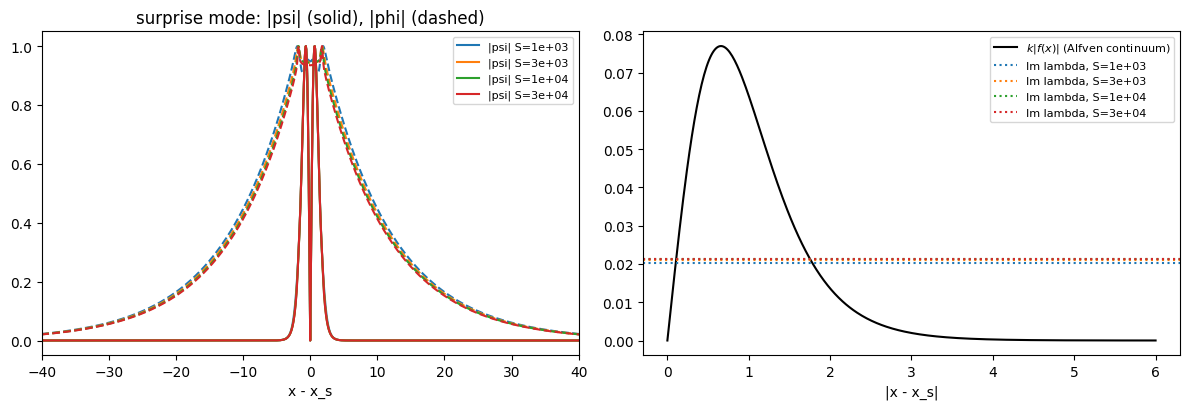

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for i, (S, r) in enumerate(SUR.items()):
    rec = r["rec"]
    axs[0].plot(rec["xf"], np.abs(rec["psif"])/np.abs(rec["psif"]).max(), color=f"C{i}", label=f"|psi| S={S:.0e}")
    axs[0].plot(rec["xf"], np.abs(rec["phif"])/np.abs(rec["phif"]).max(), color=f"C{i}", ls="--")
axs[0].set_xlim(-40, 40); axs[0].set_xlabel("x - x_s"); axs[0].legend(fontsize=8)
axs[0].set_title("surprise mode: |psi| (solid), |phi| (dashed)")
xx = np.linspace(0, 6, 400); fx = 2*np.tanh(xx)/np.cosh(xx)**2
axs[1].plot(xx, 0.1*fx, "k", label=r"$k|f(x)|$ (Alfven continuum)")
for i, (S, r) in enumerate(SUR.items()):
    axs[1].axhline(r["value"].imag, color=f"C{i}", ls=":", label=f"Im lambda, S={S:.0e}")
axs[1].set_xlabel("|x - x_s|"); axs[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Result.** The mode is real and is the same in both codes: $\lambda=6.809\times10^{-4}\pm
0.020289i$ at $S=10^3$, $ka=0.1$, converged in $n_x$ (ladder tolerance $10^{-7}$) and in $L_x$
($L_x=150$ vs 300: $4\times10^{-7}$; its frequency moves 0.9 % between $L_x=50$ and 150, so small
boxes shift it). What it
is: **twisting parity** ($\psi$ odd about the sheet, $\phi$ even -- not tearing), with $|\psi|$
peaked at $|x|=0.66$, the maximum of $|B_y|$, and $\phi$ spread over $|x|\lesssim1/k$. Its
frequency sits inside the Alfvén continuum $\omega\in k[-|f|_{max},|f|_{max}]$: $\omega/k=0.203=
|f(x_r)|$ at $x_r=1.76$ (and 0.10); $|\phi|$ has a local bump at $|x|\approx1.8$-1.9. It is unstable only at
low $S$: $\mathrm{Re}\,\lambda=+6.8\times10^{-4}$ at $S=10^3$, $-2.7\times10^{-4}$ at
$3\times10^3$, $-6.3\times10^{-4}$ at $10^4$, $-7.3\times10^{-4}$ at $3\times10^4$ -- the damping
levelling off as $\eta\to0$, the signature of continuum (resonant-absorption) damping rather
than resistive damping -- and the dense spectra show no second growing mode at $ka=0.15$ or
0.2. So: a global odd-parity Alfvén quasi-mode, coupled to the continuum at $x_r\approx\pm1.8$,
pushed weakly overstable by resistivity at $S\approx10^3$ and $ka\approx0.1$ only. It is not a
tearing mode and it is irrelevant for $S\gtrsim3\times10^3$. (Not chased further, per the plan.)

### 11. Summary

* **Theory, independently verified:** $\Delta'a=2(5-k^2a^2)(k^2a^2+3)/(k^2a^2\sqrt{k^2a^2+4})$
  (sympy ladder solution exact; shooting $10^{-12}$-$10^{-14}$); the Boldyrev & Loureiro 2018 eq.
  (60) dispersion relation (Coppi et al. 1976 / Ara et al. 1978), rescaled $k\to k|f'(0)|$, against
  a numerical inner-layer solve to $\le7\times10^{-7}$ for $\Lambda\in[10^{-3},0.97]$; FKR
  ($C=2.1236$, prefactor 0.5474) and Coppi limits both reached. B&L's printed "$C\approx1.45$" is an
  arithmetic slip; their formula is 2.124.
* **$\gamma_{eig}/\gamma_{th}\to1$:** 0.86-0.92 at $S=10^3$ $\to$ 0.992-0.998 at $S=10^6$ for
  $ka\le1.5$; the correction is $\simeq C(k)/(\gamma_{th}\tau_R)$, $\tau_R=1/(\eta(k^2+4))$, with
  $C=1.28,1.02,0.78$ constant over three decades at $ka=1,1.5,2$ (S-exponent 0.39-0.56 depending
  on regime).
* **Fastest mode:** $k_{max}\propto S^{-0.1405}$, $\gamma_{max}\propto S^{-0.4175}$ over
  $10^3$-$10^6$ (exact relation: $-0.1414$, $-0.4283$; asymptotic $-1/7$, $-3/7$ for this $n=2$
  sheet -- not the $-1/4$, $-1/2$ of $n=1$); $\gamma_{max}$ ratio 0.923 $\to$ 0.998.
* **Marginal point:** the zero stays at $\Delta'=0$ ($ka\in[2.230,2.240]\ni\sqrt5$ at
  $S=10^3$-$10^5$); finite $S$ instead suppresses growth for $\Delta'a\lesssim22S^{-1/2}$, a band
  whose width scales as $S^{-0.49}$ -- the same $\gamma\tau_R$ control as the finite-$S$ correction.
* **Layer width:** the eigenfunction's quarter-maximum $\psi''$ width converges onto the exact
  inner solution's (ratio 0.994-1.000 at $S=10^6$), in both the Coppi and FKR regimes.
* **Cross-checks:** Julia (Richardson) to $\le6\times10^{-6}$ at all 18 overlapping points; the
  time-domain notebooks to 0.3-1.1 % ($m=1$-6) once the eigenvalue is taken about their
  mid-window equilibrium amplitude; the second exact-$\Delta'$ family (two Harris-like sheets)
  resolves the double-tearing pair and tracks its exact $\Delta'_\pm$.
* **Surprise mode:** a twisting-parity, continuum-coupled Alfvén quasi-mode, overstable only at
  $S\approx10^3$, $ka\approx0.1$; present at $\alpha=0$.

**Method limits, measured:** the uniform periodic grid reached $S=10^6$ at every $ka\le1.5$ (and
$n_x=32768$, $n\approx43700$ unknowns, band-LU-preconditioned shift-invert, $\le8$ min per solve on a
loaded laptop); it runs out near marginality ($ka\ge2.2$ at $S=10^6$, $ka\ge2.23$ everywhere) where
the layer keeps thinning as $\gamma\to0$.

In [21]:
# data-generation cost: the solve times as recorded (the machine was shared; indicative only)
import glob
recs = [np.load(p) for p in glob.glob(os.path.join(T.DATA_ROOT, "solves", "*.npz"))]
secs = np.array([float(r["seconds"]) for r in recs]); nxs = np.array([int(r["nx"]) for r in recs])
size = sum(os.path.getsize(p) for p in glob.glob(os.path.join(T.DATA_ROOT, "solves", "*.npz")))
print(f"{len(recs)} cached eigen-solves, {secs.sum()/3600:.2f} h of solve time in total, "
      f"{size/2**20:.1f} MiB on disk; largest nx = {nxs.max()}, slowest solve {secs.max():.0f} s")

760 cached eigen-solves, 2.63 h of solve time in total, 74.7 MiB on disk; largest nx = 32768, slowest solve 458 s
